## **0. Importing necessary librairies**

In [1]:
from astropy.io import fits # for fits file
import matplotlib.pyplot as plt # for data visualisation
import numpy as np # for math and array
import os # to manipulate folder/directory and files

# use to not have to type the directory name each time
%cd captures/ 

/Users/lalyboyer/Desktop/software/captures


## **1. Selecting the object**

In [2]:
# variable to select a specific observation
# later on i guess it would be interesting to use it by RA/DEC, only need to change the save_fits() function

OBJECT_NAME = "TEST"
EXPOSURE = 20000
MAX_W, MAX_H = 1936, 1216 # detector pixels

### <span style="color:red">TODO : Remember header fits file metadata</span>.

## **2. Creating the master bias**

Bias-frames are primarily needed to remove the offset value from the images. This is necessary because the offset value is not part of the object signal and is fixed. Therefore, this value can be subtracted from the actual signal. A bias frame contains the offset value set by the manufacturer or previously configured by the user (see section 'Basics' - 'Offset') as well as the readout noise. Since readout noise is a random value for every frame type, it is not eliminated during subtraction. To prevent the total noise from increasing unnecessarily due to the subtraction of the different readout noise values, as many bias frames as possible are averaged.
A bias-frame is created using the camera's shortest possible exposure time, which is usually in the µs-range. With such a short exposure time, dark current is virtually nonexistent. ([source](https://astrobasics.de/en/basics/bias-flats-darks-darkflats/#:~:text=Frame-,Bias,nonexistent))

To create them, there are different type of stacking mode ([source](https://astrobackyard.com/bias-frames-astrophotography/#:~:text=I,want])):
- Average
- Median (default one)
- Kappa-Sigma clipping
- Median Kappa-Sigma clipping
- Auto Adaptive Weighted Average

    **For now, the method use is MEDIAN**

### Function

In [3]:
def master_bias(object_name):
    bias_folder = f"{object_name}/BIAS_200"
    bias_files = os.listdir(bias_folder)
    biases = np.zeros((MAX_H,MAX_W,len(bias_files)))

    for i, bias in enumerate(bias_files): # loop for each bias in the bias folder
        with fits.open(f"{bias_folder}/{bias}") as hdul: # open fits file
            biases[:,:,i] = hdul[0].data

    master_bias = np.median(biases, axis=2)
    return master_bias

In [ ]:
MASTER_BIAS = master_bias(OBJECT_NAME)

### Master bias visualisation

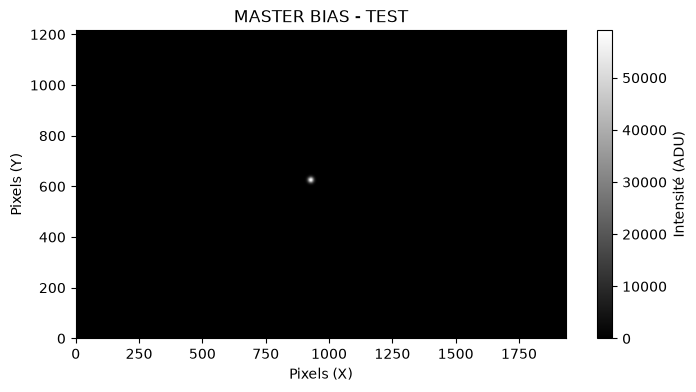

In [11]:
fig, ax = plt.subplots(figsize=(8,4))

im = ax.imshow(MASTER_BIAS, cmap='gray', origin='lower', vmin=0)#, vmax=2000)

ax.set_title(f"MASTER BIAS - {OBJECT_NAME}")
ax.set_xlabel("Pixels (X)")
ax.set_ylabel("Pixels (Y)")

# 5. Ajout de la barre de couleur liée à l'image 'im'
fig.colorbar(im, ax=ax, label="Intensité (ADU)")

plt.show()

## Spectre

In [ ]:
# # plt.imshow(data)
# def spectra(data, log=False, yline=650):
#     fig, (ax1, ax2) = plt.subplots(1,2, figsize=(15,6))

#     # primary_header = hdul[0].header
#     if log:
#         ax1.plot(np.log10(data[yline,:][::-1] +1))
#         ax1.set_ylabel("Intensity (Log10 ADU)")
#     else:
#         ax1.plot(data[yline,:][::-1])
#         ax1.set_ylabel("Intensity (ADU)")

#     # ax1.set_title(f"FITS - {primary_header['DATE-OBS']}\n EXP : {primary_header['EXPTIME']} - GAIN : {primary_header['GAIN']}\n OBJ : {primary_header['OBJECT']}- RA : {primary_header['RA']} - DEC : {primary_header['DEC']}")
#     ax1.set_xlabel("Pixels (X)")

#     ax1.grid(ls='--',c='lightgrey')
#     ax1.set_axisbelow(True)

#     im = ax2.imshow(data, cmap='gray', origin='lower', vmin=0)#, vmax=2000)
    
#     # On trace la ligne rouge horizontale là où la coupe est faite
#     ax2.axhline(y=yline, color='red', linestyle='--', linewidth=1.5, label=f'Coupe Y={yline}')
    
#     ax2.set_title("Detector image (2D)")
#     ax2.set_xlabel("Pixels (X)")
#     ax2.set_ylabel("Pixels (Y)")
#     ax2.legend(loc='upper right') # Pour afficher le petit badge de la ligne rouge

#     # 3. Barre de couleur uniquement pour l'image 2D (im)
#     fig.colorbar(im, ax=ax2, label="Intensité (ADU)", fraction=0.046, pad=0.04)

#     # # 4. Titre général de la figure avec les métadonnées
#     # fig.suptitle(f"FITS - {header['DATE-OBS']} | OBJ : {header['OBJECT']}\n"
#     #              f"EXP : {header['EXPTIME']} µs | GAIN : {header['GAIN']} dB | IMGMODE : {header['IMGMODE']}\nRA/DEC : {header['RA']}/{header['DEC']}", 
#     #              fontsize=12, y=0.98)

#     plt.tight_layout() # Aligne proprement les graphiques sans qu'ils se chevauchent
#     plt.show()

#     # 5. Ajout de la barre de couleur liée à l'image 'im'

#     plt.show()

# # spectra(False, 1000)


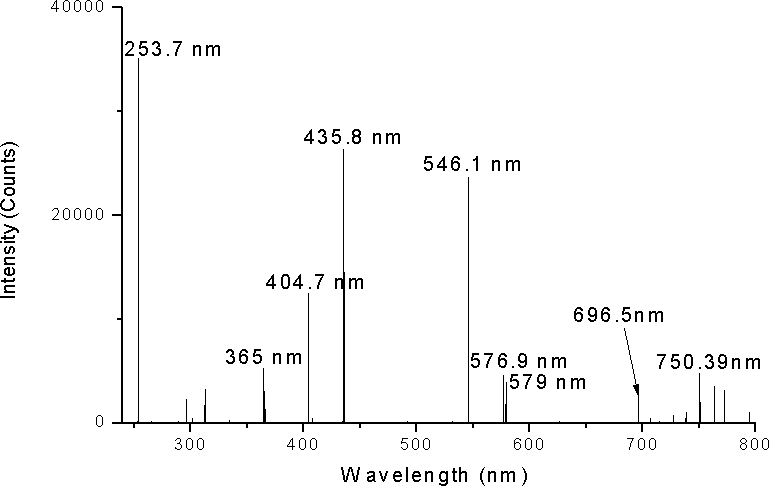

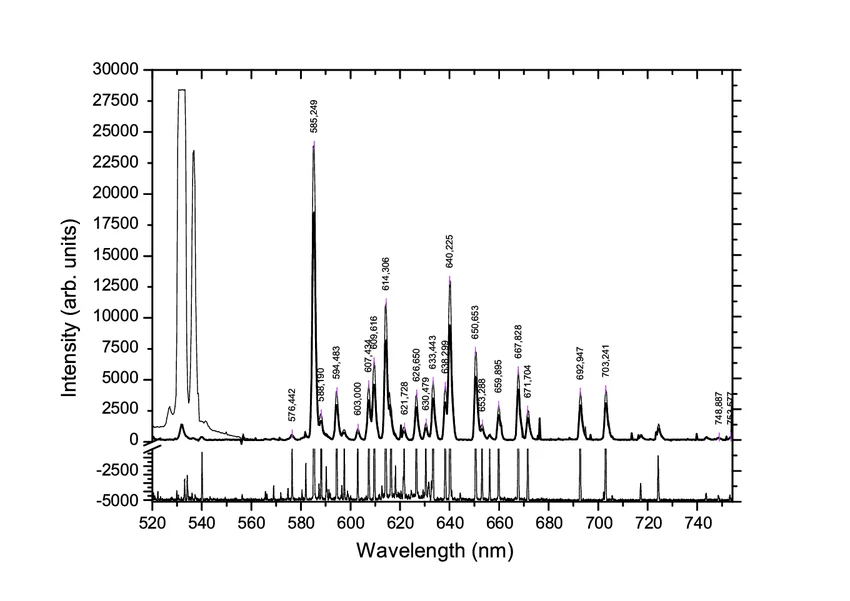

## HgAr

In [ ]:
# import os
# import numpy as np
# from astropy.io import fits
# import matplotlib.pyplot as plt

# %cd
# %cd Desktop/software/captures
# %cd hgar
# %pwd

# biases = np.zeros((1216, 1936, len(os.listdir('bias'))))
# for i, bias in enumerate(os.listdir('bias')):
#     bias_path = os.path.join('bias', bias)
#     biases[:,:,i] = (fits.open(bias_path)[0].data)

# bias_median = np.median(biases, axis=2)

# darks = np.zeros((1216, 1936, len(os.listdir('dark_50000'))))
# for i, dark in enumerate(os.listdir('dark_50000')):
#     dark_path = os.path.join('dark_50000', dark)
#     darks[:,:,i] = (fits.open(dark_path)[0].data) - bias_median

# dark_median = np.median(darks, axis=2)



# sciences = np.zeros((1216, 1936, len(os.listdir('science_50000'))))
# for i, science in enumerate(os.listdir('science_50000')):
#     science_path = os.path.join('science_50000', science)
#     sciences[:,:,i] = (fits.open(science_path)[0].data)

# science_median = np.median(sciences, axis=2)


# # quick visual check
# plt.figure(figsize=(8,5))
# plt.imshow(science_median - dark_median, cmap='gray', origin='lower')
# plt.colorbar(label='ADU')
# plt.title('Master dark (median)')
# plt.show()

# final_im = science_median - dark_median

# spectra(final_im)